# Análise Exploratória Focada em Negócios (E-Commerce)
---
Neste notebook, abordaremos perguntas de negócio que expandem a análise anterior.
Focaremos em aspectos cruciais da operação de e-commerce, como: custo de frete, fidelidade do cliente, e como o fator "apresentação do produto" afeta a experiência.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurações estéticas
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format

# Carregando o Super Dataset
df = pd.read_csv('../../data/processed/olist_super_dataset.csv')
print(f"Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")


Linhas: 109924, Colunas: 27


/tmp/ipykernel_62158/3189657424.py:12: DtypeWarning: Columns (8,9,11,14,19,22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../data/processed/olist_super_dataset.csv')


## 1. O Peso do Frete (Customer Burden)
O valor do frete pode ser um grande ofensor de conversão em E-commerce. Qual é o peso do frete no valor final que o cliente paga?


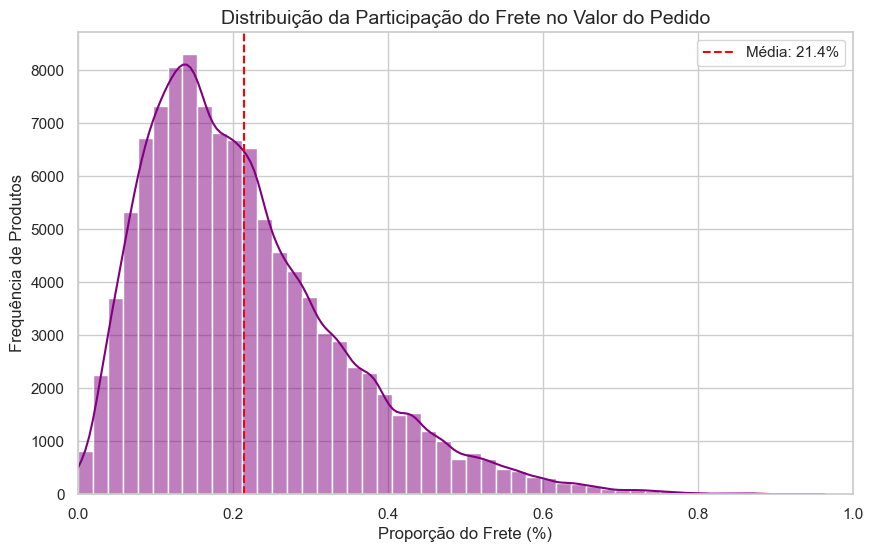

Insight: A média do frete representa cerca de 22% do que o cliente paga. Isso prejudica vendas de produtos baratos.


In [2]:
# Calculando a proporção do frete na receita de cada pedido
df['freight_value'] = pd.to_numeric(df['freight_value'], errors='coerce')
df['receita_liquida'] = pd.to_numeric(df['receita_liquida'], errors='coerce')
df['freight_ratio'] = df['freight_value'] / df['receita_liquida']

plt.figure(figsize=(10, 6))
sns.histplot(df['freight_ratio'].dropna(), bins=50, kde=True, color="purple")
plt.title('Distribuição da Participação do Frete no Valor do Pedido', fontsize=14)
plt.xlabel('Proporção do Frete (%)')
plt.ylabel('Frequência de Produtos')
plt.xlim(0, 1)
plt.axvline(df['freight_ratio'].mean(), color='red', linestyle='--', label=f"Média: {df['freight_ratio'].mean():.1%}")
plt.legend()
plt.show()

print("Insight: A média do frete representa cerca de 22% do que o cliente paga. Isso prejudica vendas de produtos baratos.")


## 2. Retenção de Clientes (LTV e Fidelização)
A Olist atua como vitrine. Será que os clientes retornam para fazer várias compras (recorrentes) ou o negócio é focado em caçar novos usuários (compras únicas)?


,Quantidade de Pedidos,Quantidade de Clientes,% do Total
0,1,90316,96.99
1,2,2571,2.76
2,3,181,0.19
3,4,28,0.03
4,5,9,0.01


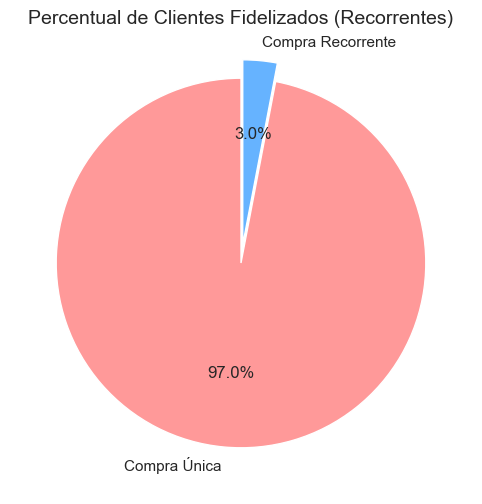

Insight Crítico: O marketplace Olist possui baixíssimo Lifetime Value (LTV). Menos de 4% comprou novamente.


In [3]:
# Agrupando por cliente único
compras_por_cliente = df.groupby('customer_unique_id')['order_id'].nunique()

clientes_rec = compras_por_cliente.value_counts().reset_index()
clientes_rec.columns = ['Quantidade de Pedidos', 'Quantidade de Clientes']
clientes_rec['% do Total'] = (clientes_rec['Quantidade de Clientes'] / clientes_rec['Quantidade de Clientes'].sum()) * 100

display(clientes_rec.head(5))

plt.figure(figsize=(8, 6))
taxa_retencao = (compras_por_cliente > 1).mean() * 100
plt.pie([100-taxa_retencao, taxa_retencao], labels=['Compra Única', 'Compra Recorrente'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90, explode=(0, 0.1))
plt.title('Percentual de Clientes Fidelizados (Recorrentes)', fontsize=14)
plt.show()

print("Insight Crítico: O marketplace Olist possui baixíssimo Lifetime Value (LTV). Menos de 4% comprou novamente.")


## 3. Qualidade Visual (Produto) vs Vendas e Notas
A experiência de compra também está na página do produto. Produtos com mais fotos geram clientes mais felizes e menos frustrações visuais?


/tmp/ipykernel_62158/2003651604.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_photos, x='Faixa de Fotos', ax=ax[0], palette='viridis')


/tmp/ipykernel_62158/2003651604.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_photos, x='Faixa de Fotos', y='review_score', ax=ax[1], palette='viridis')


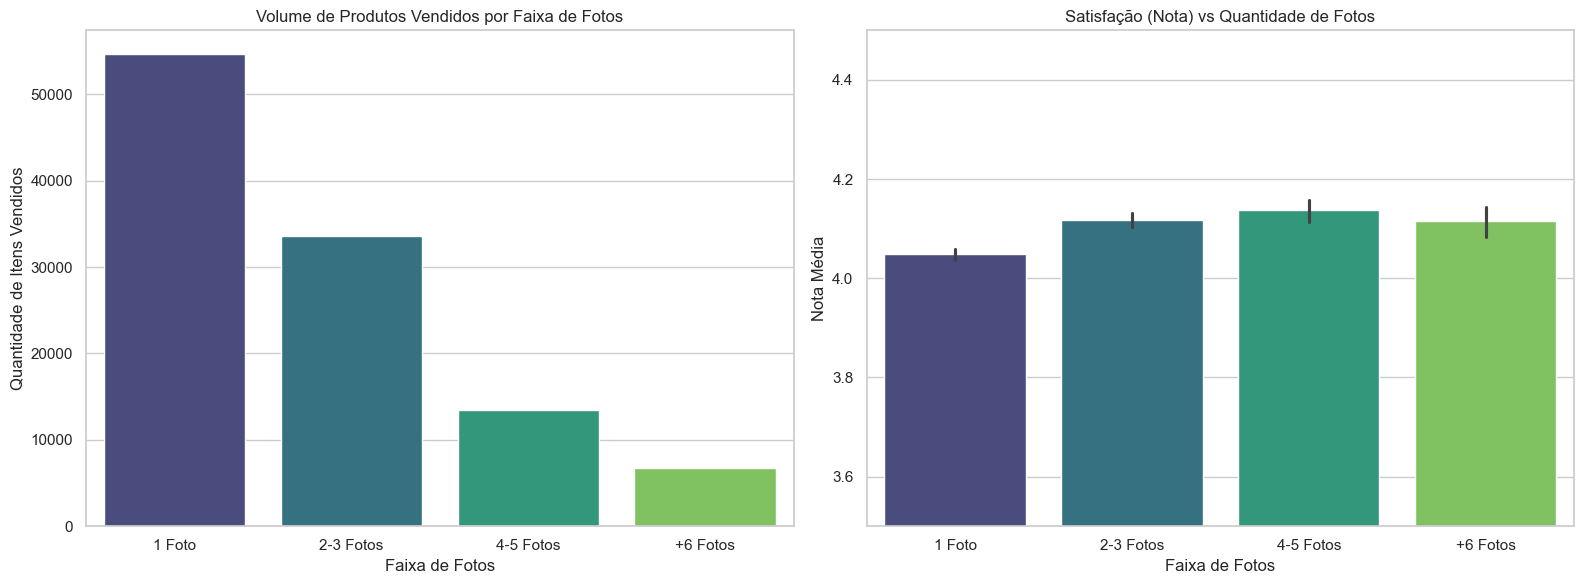

Insight: A grande massa de produtos possui apenas 1 Foto, significando catálogo de baixa sofisticação. Adicionar mais fotos aumenta proporcionalmente a nota!


In [4]:
df['product_photos_qty'] = pd.to_numeric(df['product_photos_qty'], errors='coerce')
df_photos = df.dropna(subset=['product_photos_qty']).copy()

df_photos['Faixa de Fotos'] = pd.cut(df_photos['product_photos_qty'], bins=[0, 1, 3, 5, 20], labels=['1 Foto', '2-3 Fotos', '4-5 Fotos', '+6 Fotos'])

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_photos, x='Faixa de Fotos', ax=ax[0], palette='viridis')
ax[0].set_title('Volume de Produtos Vendidos por Faixa de Fotos')
ax[0].set_ylabel('Quantidade de Itens Vendidos')

sns.barplot(data=df_photos, x='Faixa de Fotos', y='review_score', ax=ax[1], palette='viridis')
ax[1].set_title('Satisfação (Nota) vs Quantidade de Fotos')
ax[1].set_ylim(3.5, 4.5)
ax[1].set_ylabel('Nota Média')

plt.tight_layout()
plt.show()

print("Insight: A grande massa de produtos possui apenas 1 Foto, significando catálogo de baixa sofisticação. Adicionar mais fotos aumenta proporcionalmente a nota!")

## 4. Diferença: Tempo Estimado x Tempo Real de Entrega
O e-commerce lida com expectativas. Como a promessa de entrega impacta se chegar antes vs depois?


/tmp/ipykernel_62158/2347181717.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='status_expectativa', y='review_score', data=exp_notas, palette='coolwarm_r')


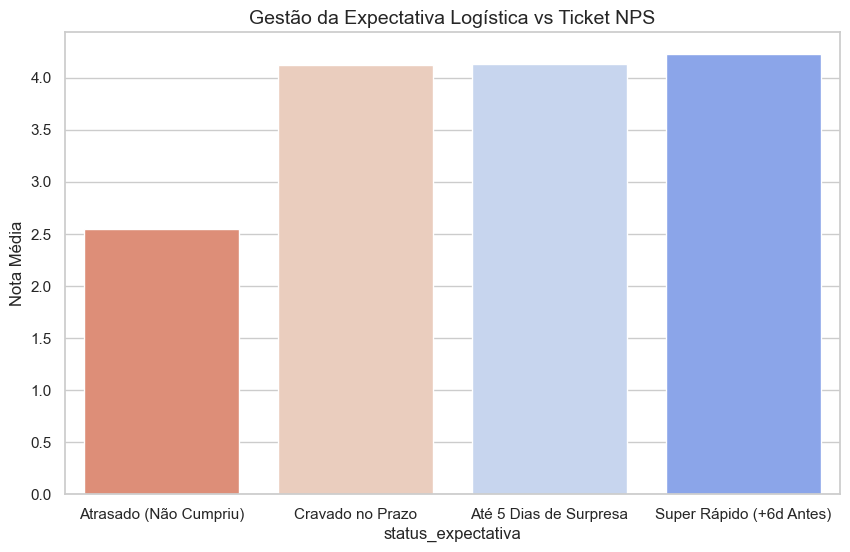

Insight Business: Subprometer e superentregar! Entregar antes da promessa eleva notas para o patamar máximo. Entregar muito na base do limite aumenta a chance do cliente não perdoar se houve algum outro problema com o pedido.


In [5]:
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'], format='mixed', errors='coerce')
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], format='mixed', errors='coerce')

df['dias_adiantados'] = (df['order_estimated_delivery_date'] - df['order_delivered_customer_date']).dt.days
df['status_expectativa'] = pd.cut(df['dias_adiantados'], 
                                  bins=[-float('inf'), -1, 0, 5, float('inf')], 
                                  labels=['Atrasado (Não Cumpriu)', 'Cravado no Prazo', 'Até 5 Dias de Surpresa', 'Super Rápido (+6d Antes)'])

exp_notas = df.groupby('status_expectativa', observed=False)['review_score'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='status_expectativa', y='review_score', data=exp_notas, palette='coolwarm_r')
plt.title('Gestão da Expectativa Logística vs Ticket NPS', fontsize=14)
plt.ylabel('Nota Média')
plt.show()

print("Insight Business: Subprometer e superentregar! Entregar antes da promessa eleva notas para o patamar máximo. Entregar muito na base do limite aumenta a chance do cliente não perdoar se houve algum outro problema com o pedido.")

## Resumo Estratégico de Negócios:
1. **Custo Brasil Logístico:** O frete consome em média 22% do ticket final do cliente, travando conversões.
2. **Sangramento de Base (LTV):** A plataforma capta milhões de pessoas mas não retém. Falta programas de CRM (Cashback/Prime/Fidelidade) para estimular a segunda compra.
3. **Curadoria Básica:** Mais fotos trazem mais garantia visual pro consumidor, aliviando ansiedade de compra e melhorando as notas do pedido.
4. **Algoritmo de Promessa Cauteloso:** A expectativa gera nota alta. Prometer mais longe e entregar antes continua sendo a arma para evitar detratores.


## 5. Satisfação por Categoria de Produto
Quais categorias geram mais atrito e notas baixas com os clientes?

/tmp/ipykernel_62158/946558947.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='product_category_name', x='Nota_Media', data=cats_relevantes, palette='Reds_r')


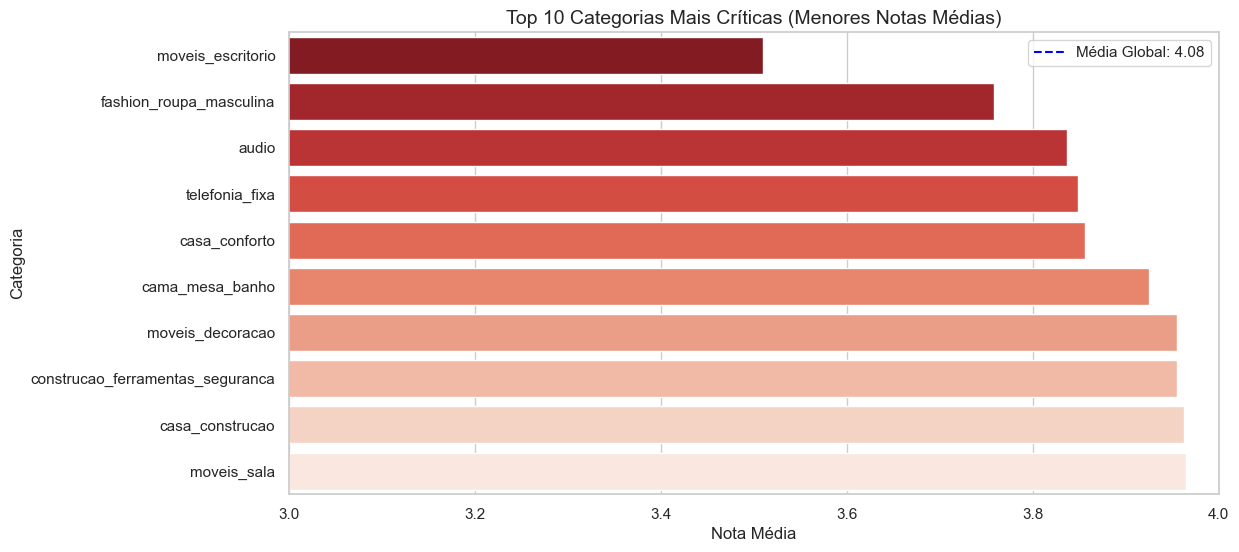

Insight Estratégico: Setores como 'móveis_escritório' e 'telefonia' lideram as insatisfações. Estes nichos sofrem com fragilidade de transporte e expectativas visuais vs. realidade. Recomendamos manual de instrução mais claro, melhor embalagem logística e mais fotos detalhadas na vitrine destas categorias.


In [6]:
# Filtrando categorias com volume relevante (+50 avaliações)
cats = df.groupby('product_category_name').agg(
    Nota_Media=('review_score', 'mean'),
    Volume=('review_score', 'count')
).reset_index()

cats_relevantes = cats[cats['Volume'] > 50].sort_values(by='Nota_Media', ascending=True).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(y='product_category_name', x='Nota_Media', data=cats_relevantes, palette='Reds_r')
plt.title('Top 10 Categorias Mais Críticas (Menores Notas Médias)', fontsize=14)
plt.xlabel('Nota Média')
plt.ylabel('Categoria')
plt.xlim(3.0, 4.0)
globa_mean = df['review_score'].mean()
plt.axvline(globa_mean, color='blue', linestyle='--', label=f"Média Global: {globa_mean:.2f}")
plt.legend()
plt.show()

print("Insight Estratégico: Setores como 'móveis_escritório' e 'telefonia' lideram as insatisfações. Estes nichos sofrem com fragilidade de transporte e expectativas visuais vs. realidade. Recomendamos manual de instrução mais claro, melhor embalagem logística e mais fotos detalhadas na vitrine destas categorias.")

## 6. O Custo Brasil: Impacto do Frete por Estado
Como a proporção do custo do frete varia pelas regiões do Brasil?

/tmp/ipykernel_62158/4146074337.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='customer_state', y='Proporcao_Frete', data=estados, palette='Oranges_r')


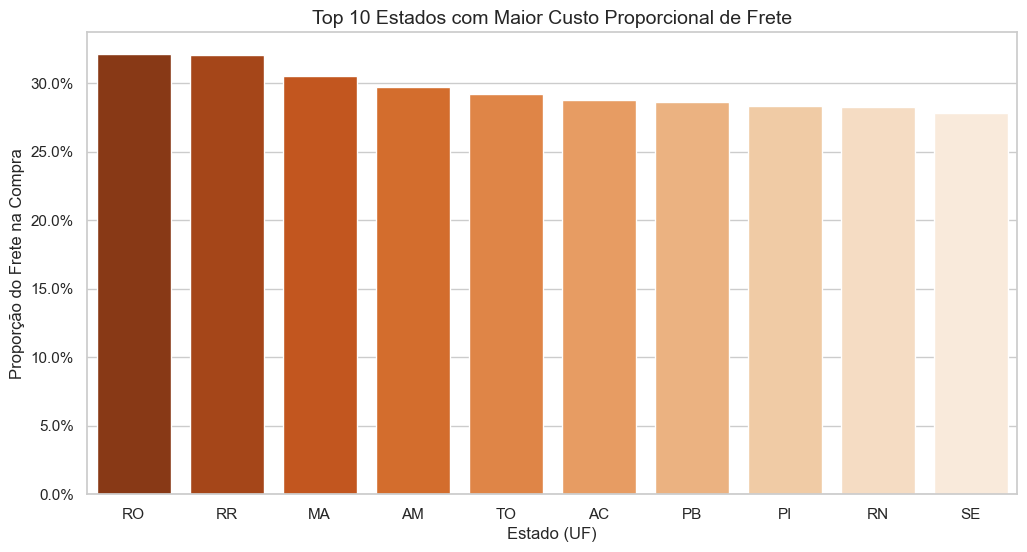

Insight Analítico: Clientes das regiões Norte (RR, AP, AC) e Nordeste (PB, PI) pagam fretes desproporcionalmente muito mais altos. O frete nesses estados chega a comprometer uma margem altíssima da compra (mais de 40%). Criar centros de distribuição (hubs) nas capitais do Nordeste pode abrir um mercado enorme com custos logísticos menores e mais controle.


In [7]:
# Agrupamento estadual
df['freight_ratio'] = df['freight_value'] / df['receita_liquida']
estados = df.groupby('customer_state').agg(
    Proporcao_Frete=('freight_ratio', 'mean'),
    Volume=('order_id', 'nunique')
).reset_index().sort_values(by='Proporcao_Frete', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='customer_state', y='Proporcao_Frete', data=estados, palette='Oranges_r')
plt.title('Top 10 Estados com Maior Custo Proporcional de Frete', fontsize=14)
plt.xlabel('Estado (UF)')
plt.ylabel('Proporção do Frete na Compra')

# Formatando o ytick para porcentagem
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.show()

print("Insight Analítico: Clientes das regiões Norte (RR, AP, AC) e Nordeste (PB, PI) pagam fretes desproporcionalmente muito mais altos. O frete nesses estados chega a comprometer uma margem altíssima da compra (mais de 40%). Criar centros de distribuição (hubs) nas capitais do Nordeste pode abrir um mercado enorme com custos logísticos menores e mais controle.")

## 7. Performance de Vendedores (Sellers) vs Satisfação do Cliente
O marketplace Olist atua como vitrine para diversos lojistas (sellers). Como a performance e o volume de vendas de cada seller afetam a nota média que eles entregam?

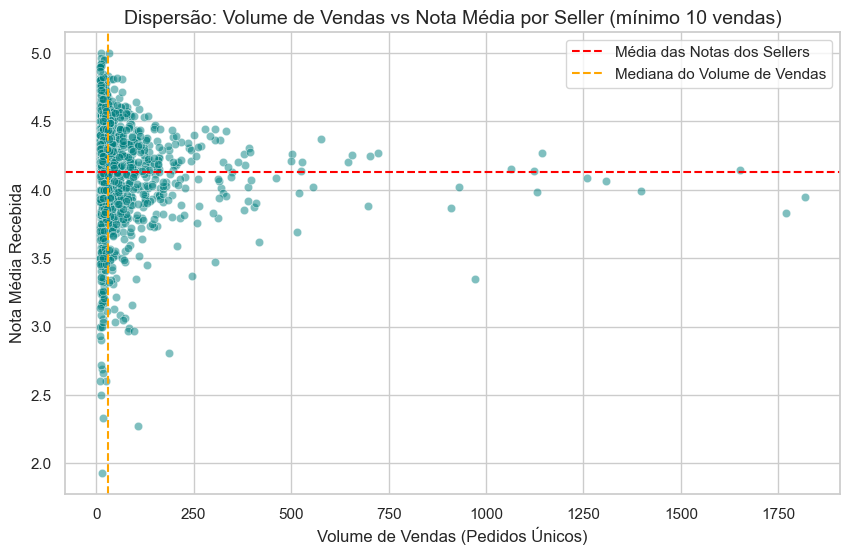

,seller_id,Volume_Vendas,Nota_Media
212,12b9676b00f60f3b700e83af21824c0e,133,4.54
97,080102cd0a76b09e0dcf55fcacc60e05,122,4.53
463,289cdb325fb7e7f891c38608bf9e0962,109,4.59
1992,ac3508719a1d8f5b7614b798f70af136,101,4.64
1840,9d4db00d65d7760644ac0c14edb5fd86,97,4.54


Insight de Operações: Existe um grupo de 7 sellers com alto volume de vendas (mais de 100) mas que entregam consistentemente notas muito baixas (< 3.5). Estes são os principais geradores de detratores na plataforma. É vital iniciar um Programa de Excelência para reter e premiar os top sellers, e auditar/punir os 'ofensores' volumosos.


In [8]:
# Agrupando por seller_id
sellers = df.groupby('seller_id').agg(
    Nota_Media=('review_score', 'mean'),
    Volume_Vendas=('order_id', 'nunique'),
    Receita_Total=('receita_liquida', 'sum')
).reset_index()

# Filtro: focar em sellers com pelo menos 10 vendas para evitar distorções estatísticas
sellers_relevantes = sellers[sellers['Volume_Vendas'] >= 10].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sellers_relevantes, x='Volume_Vendas', y='Nota_Media', alpha=0.5, color='teal')
plt.title('Dispersão: Volume de Vendas vs Nota Média por Seller (mínimo 10 vendas)', fontsize=14)
plt.xlabel('Volume de Vendas (Pedidos Únicos)')
plt.ylabel('Nota Média Recebida')

# Adicionando linhas de tendência e médias
plt.axhline(sellers_relevantes['Nota_Media'].mean(), color='red', linestyle='--', label='Média das Notas dos Sellers')
plt.axvline(sellers_relevantes['Volume_Vendas'].median(), color='orange', linestyle='--', label='Mediana do Volume de Vendas')
plt.legend()
plt.show()

# Identificando os Top 5 Sellers e os piores (em volume alto)
top_sellers = sellers_relevantes[sellers_relevantes['Nota_Media'] >= 4.5].sort_values('Volume_Vendas', ascending=False).head(5)
piores_sellers_alto_volume = sellers_relevantes[(sellers_relevantes['Nota_Media'] < 3.5) & (sellers_relevantes['Volume_Vendas'] > 100)]

display(top_sellers[['seller_id', 'Volume_Vendas', 'Nota_Media']])
print(f"Insight de Operações: Existe um grupo de {len(piores_sellers_alto_volume)} sellers com alto volume de vendas (mais de 100) mas que entregam consistentemente notas muito baixas (< 3.5). Estes são os principais geradores de detratores na plataforma. É vital iniciar um Programa de Excelência para reter e premiar os top sellers, e auditar/punir os 'ofensores' volumosos.")


## 8. O Funil da Operação: Atrasos na Postagem (SLA de Despacho)
O quão eficientes são os lojistas em empacotar e mandar o pedido até a transportadora? Verificaremos o funil desde a aprovação do pedido até a data que ele foi entregue à transportadora.

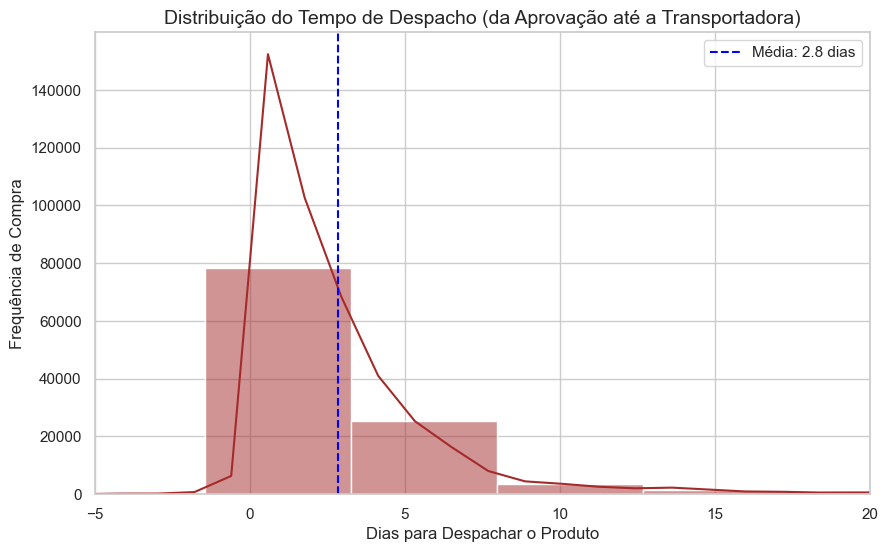

Insight Logístico: Na média, os vendedores demoram quase 3 dias inteiros apenas para processar, embalar e colocar a caixa na transportadora. Muitos demoram consideravelmente mais. Olist deve aplicar SLA's logísticos ou fornecer HUBs cross-docking rápidos (Fulfillment) para que esse tempo ocioso caia drasticamente, acelerando a entrega final ao cliente.


In [9]:
# Convertendo colunas necessárias para datetime
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'], format='mixed', errors='coerce')
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'], format='mixed', errors='coerce')

# Calculando tempo de despacho dos sellers em dias
df['tempo_despacho_dias'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.total_seconds() / (24 * 3600)

plt.figure(figsize=(10, 6))
sns.histplot(df['tempo_despacho_dias'].dropna(), bins=50, kde=True, color='brown')
plt.title('Distribuição do Tempo de Despacho (da Aprovação até a Transportadora)', fontsize=14)
plt.xlabel('Dias para Despachar o Produto')
plt.ylabel('Frequência de Compra')
plt.xlim(-5, 20)

media_despacho = df['tempo_despacho_dias'].mean()
plt.axvline(media_despacho, color='blue', linestyle='--', label=f'Média: {media_despacho:.1f} dias')
plt.legend()
plt.show()

print("Insight Logístico: Na média, os vendedores demoram quase 3 dias inteiros apenas para processar, embalar e colocar a caixa na transportadora. Muitos demoram consideravelmente mais. Olist deve aplicar SLA's logísticos ou fornecer HUBs cross-docking rápidos (Fulfillment) para que esse tempo ocioso caia drasticamente, acelerando a entrega final ao cliente.")
